In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from bilby.gw.conversion import lambda_1_lambda_2_to_lambda_tilde, lambda_1_lambda_2_to_delta_lambda_tilde, lambda_tilde_delta_lambda_tilde_to_lambda_1_lambda_2

In [2]:
narrow_df = pd.read_csv("../../events/gw/gw_params_narrow.dat", sep=" ")
events = pd.read_csv("events.dat", sep=" ")

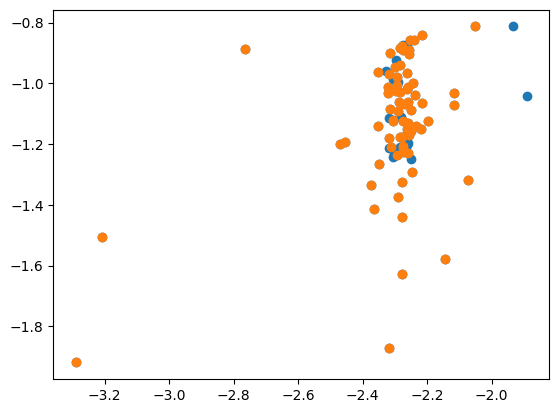

In [3]:
mask = events["inclination_EM"] > np.deg2rad(20)

plt.scatter(events["log10_mej_dyn"], events["log10_mej_wind"])
plt.scatter(events["log10_mej_dyn"][mask], events["log10_mej_wind"][mask])

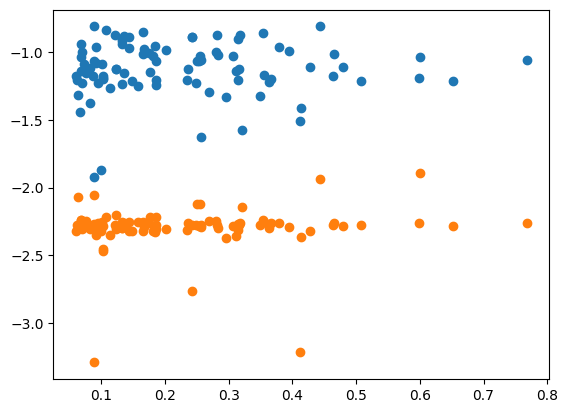

In [7]:
plt.scatter(events["redshift"], events["log10_mej_wind"])
plt.scatter(events["redshift"], events["log10_mej_dyn"])

(array([ 3.,  1.,  5., 20., 17., 14.,  8.,  9.,  4., 11.]),
 array([0.07808737, 0.15009567, 0.22210396, 0.29411225, 0.36612055,
        0.43812884, 0.51013713, 0.58214543, 0.65415372, 0.72616201,
        0.79817031]),
 <BarContainer object of 10 artists>)

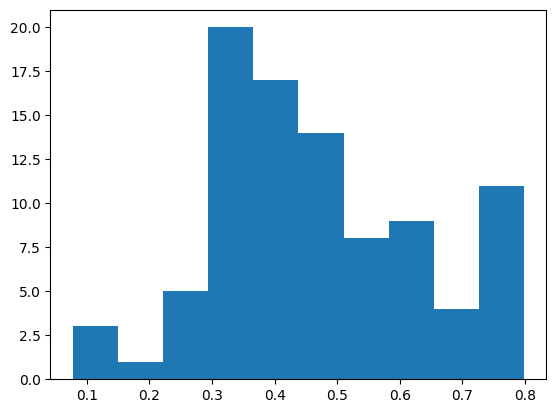

In [11]:
plt.hist(10**(events["log10_mej_wind"] - events["log10_mdisk"]))

In [14]:
events["log10_mej_wind"].argmin()

np.int64(34)

In [15]:
events.loc[34]

redshift                          0.087684
luminosity_distance             413.837209
mass_1_source                     1.571735
mass_2_source                     1.293563
chi_eff                           0.045954
chi_1                             0.083776
chi_2                                  0.0
mass_1                             1.70955
mass_2                            1.406987
radius_1                         12.098355
radius_2                         12.182818
lambda_1                        180.683935
lambda_2                        618.947045
theta_jn                          0.980266
phase                             3.599552
psi                               1.579582
ra                                5.635718
dec                              -0.542137
geocent_time             2233897432.773566
prompt_collapse                          1
inclination_EM                    0.980266
log10_mej_dyn                    -3.288283
v_ej_dyn                           0.22575
Ye_dyn     

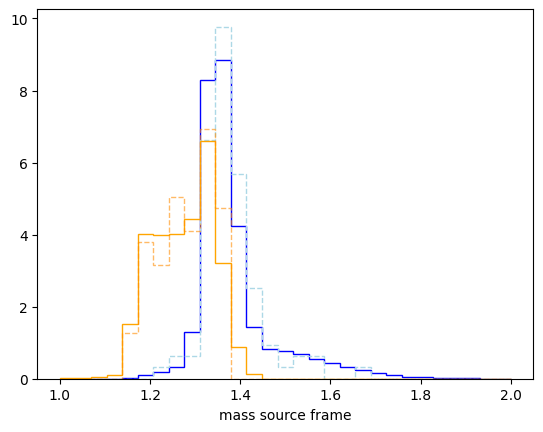

In [12]:
bins = np.linspace(1, 2, 30)

plt.hist(narrow_df["mass_1_source"], bins=bins, density=True, histtype="step", color="blue")
plt.hist(events.loc[:, "mass_1_source"], bins=bins, density=True, histtype="step", color="lightblue", linestyle="dashed")

plt.hist(narrow_df["mass_2_source"], bins=bins, density=True, color="orange", histtype="step")
plt.hist(events.loc[:, "mass_2_source"], bins=bins, density=True, histtype="step", alpha=0.6, color="darkorange", linestyle="dashed")


plt.xlabel("mass source frame")
plt.show()